<h2 align=center>Multimodal deep learning model integrating cnn and transformer for predicting chemotherapy induced cardiotoxicity</h2>

### import necessary packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("archive/CVD_cleaned.csv")
df

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308849,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,25-29,168.0,81.65,29.05,No,4.0,30.0,8.0,0.0
308850,Fair,Within the past 5 years,Yes,No,No,No,No,Yes,No,Male,65-69,180.0,69.85,21.48,No,8.0,15.0,60.0,4.0
308851,Very Good,5 or more years ago,Yes,No,No,No,Yes,"Yes, but female told only during pregnancy",No,Female,30-34,157.0,61.23,24.69,Yes,4.0,40.0,8.0,4.0
308852,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,65-69,183.0,79.38,23.73,No,3.0,30.0,12.0,0.0


In [3]:
#seeing top 5 record in table
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0


In [4]:
#seeing bottom 5 record in table
df.tail()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
308849,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,25-29,168.0,81.65,29.05,No,4.0,30.0,8.0,0.0
308850,Fair,Within the past 5 years,Yes,No,No,No,No,Yes,No,Male,65-69,180.0,69.85,21.48,No,8.0,15.0,60.0,4.0
308851,Very Good,5 or more years ago,Yes,No,No,No,Yes,"Yes, but female told only during pregnancy",No,Female,30-34,157.0,61.23,24.69,Yes,4.0,40.0,8.0,4.0
308852,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,65-69,183.0,79.38,23.73,No,3.0,30.0,12.0,0.0
308853,Excellent,Within the past year,Yes,No,No,No,No,No,No,Female,45-49,160.0,81.19,31.71,No,1.0,5.0,12.0,1.0


In [5]:
#let see the datatype of each column
df.dtypes

General_Health                   object
Checkup                          object
Exercise                         object
Heart_Disease                    object
Skin_Cancer                      object
Other_Cancer                     object
Depression                       object
Diabetes                         object
Arthritis                        object
Sex                              object
Age_Category                     object
Height_(cm)                     float64
Weight_(kg)                     float64
BMI                             float64
Smoking_History                  object
Alcohol_Consumption             float64
Fruit_Consumption               float64
Green_Vegetables_Consumption    float64
FriedPotato_Consumption         float64
dtype: object

In [6]:
# checking any null values in the column
df.isnull().sum()

General_Health                  0
Checkup                         0
Exercise                        0
Heart_Disease                   0
Skin_Cancer                     0
Other_Cancer                    0
Depression                      0
Diabetes                        0
Arthritis                       0
Sex                             0
Age_Category                    0
Height_(cm)                     0
Weight_(kg)                     0
BMI                             0
Smoking_History                 0
Alcohol_Consumption             0
Fruit_Consumption               0
Green_Vegetables_Consumption    0
FriedPotato_Consumption         0
dtype: int64

In [7]:
# checking any null values in the column
df.isnull().sum().sum()

np.int64(0)

In [8]:
# checking any duplicates records in tha table
df.duplicated().sum()

np.int64(80)

In [9]:
# If you want to reset the index after dropping 
df = df.drop_duplicates().reset_index(drop=True)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Height_(cm),308774.0,170.615220,10.658452,91.00,163.00,170.00,178.00,241.00
Weight_(kg),308774.0,83.590399,21.344664,24.95,68.04,81.65,95.25,293.02
BMI,308774.0,28.626813,6.522810,12.02,24.21,27.44,31.85,99.33
Alcohol_Consumption,308774.0,5.097557,8.200434,0.00,0.00,1.00,6.00,30.00
Fruit_Consumption,308774.0,29.834290,24.877812,0.00,12.00,30.00,30.00,120.00
Green_Vegetables_Consumption,308774.0,15.109517,14.926912,0.00,4.00,12.00,20.00,128.00
FriedPotato_Consumption,308774.0,6.297237,8.583837,0.00,2.00,4.00,8.00,128.00


In [12]:
# seeing unique values in each column
df.nunique()

General_Health                     5
Checkup                            5
Exercise                           2
Heart_Disease                      2
Skin_Cancer                        2
Other_Cancer                       2
Depression                         2
Diabetes                           4
Arthritis                          2
Sex                                2
Age_Category                      13
Height_(cm)                       99
Weight_(kg)                      525
BMI                             3654
Smoking_History                    2
Alcohol_Consumption               31
Fruit_Consumption                 77
Green_Vegetables_Consumption      75
FriedPotato_Consumption           69
dtype: int64

C:\Users\1158\AppData\Local\Temp\ipykernel_19296\1058708353.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=target)


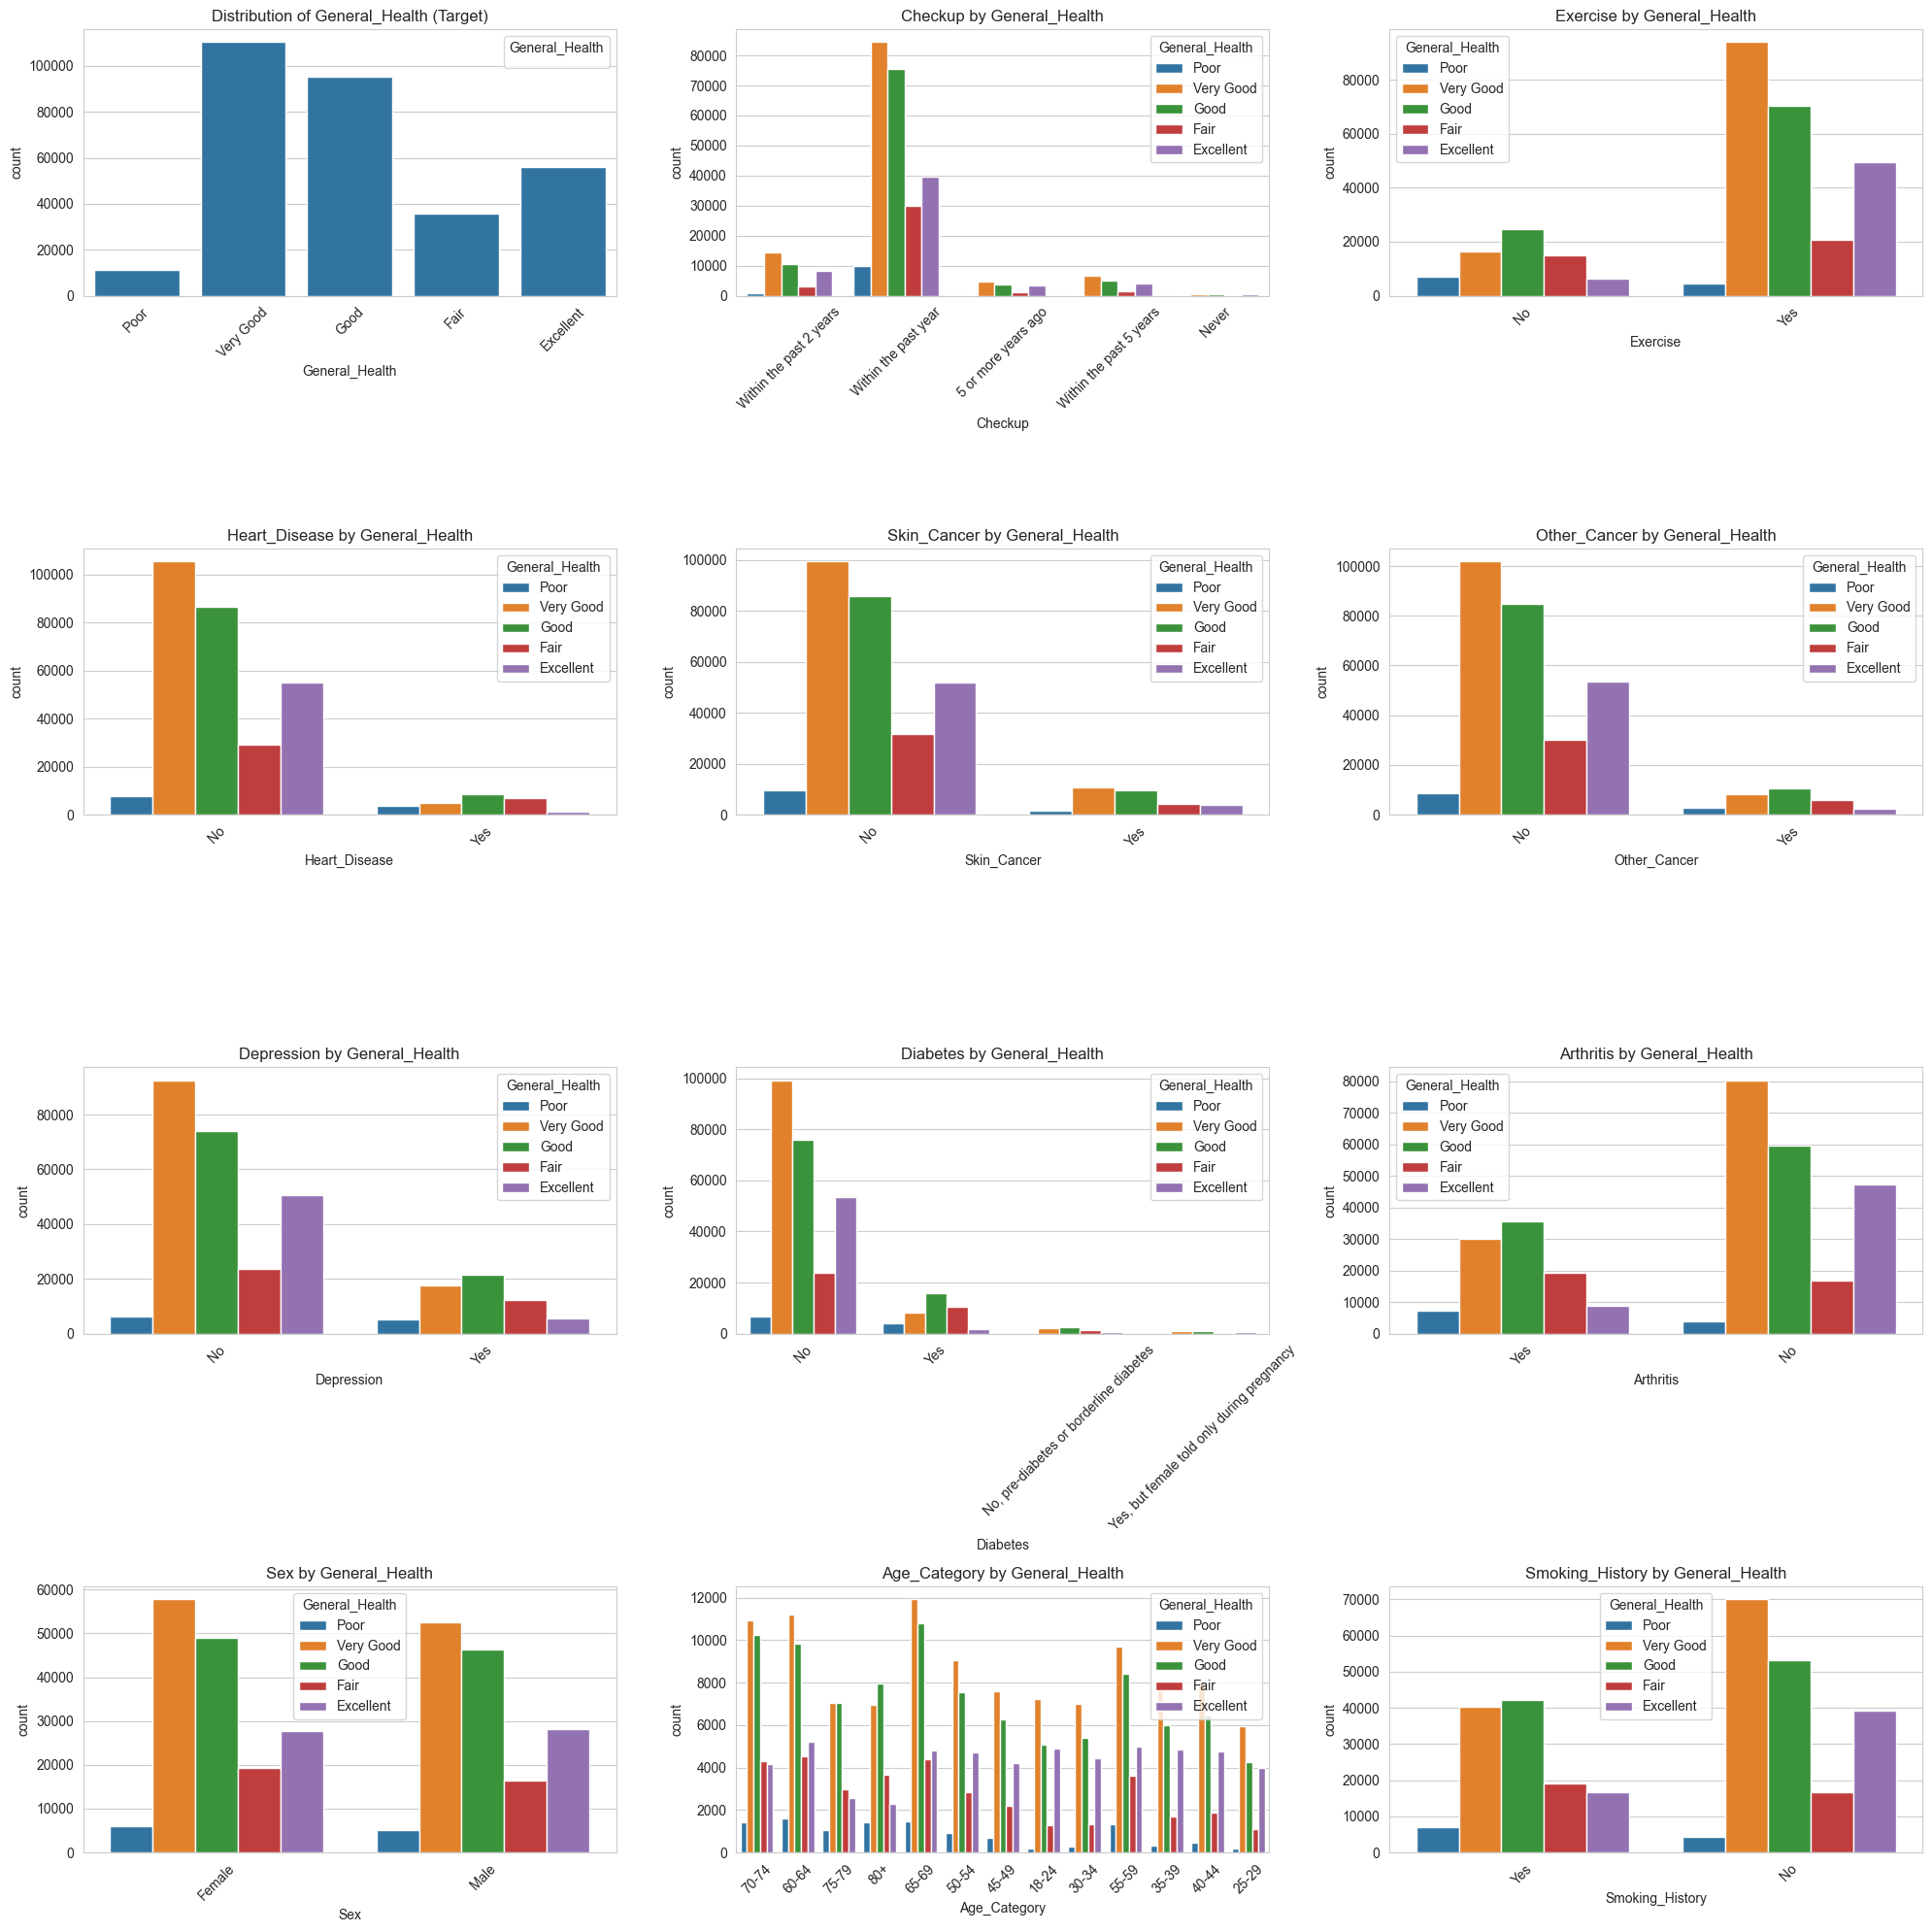

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Identify categorical and numerical columns based on your data
categorical_cols = [
    'General_Health', 'Checkup', 'Exercise', 'Heart_Disease',
    'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes',
    'Arthritis', 'Sex', 'Age_Category', 'Smoking_History'
]

numerical_cols = [
    'Height_(cm)', 'Weight_(kg)', 'BMI',
    'Alcohol_Consumption', 'Fruit_Consumption',
    'Green_Vegetables_Consumption', 'FriedPotato_Consumption'
]

target = 'General_Health'

# 1. Count plots for all categorical features (with hue on target for relationship insight)
n_cats = len(categorical_cols)
cols = 3
rows = (n_cats // cols) + (1 if n_cats % cols else 0)

plt.figure(figsize=(20, 5 * rows))
for i, col in enumerate(categorical_cols):
    plt.subplot(rows, cols, i + 1)
    if col == target:
        sns.countplot(data=df, x=col)
        plt.title(f'Distribution of {col} (Target)')
    else:
        sns.countplot(data=df, x=col, hue=target)
        plt.title(f'{col} by {target}')
    plt.xticks(rotation=45)
    plt.legend(title=target)
plt.tight_layout()
plt.show()


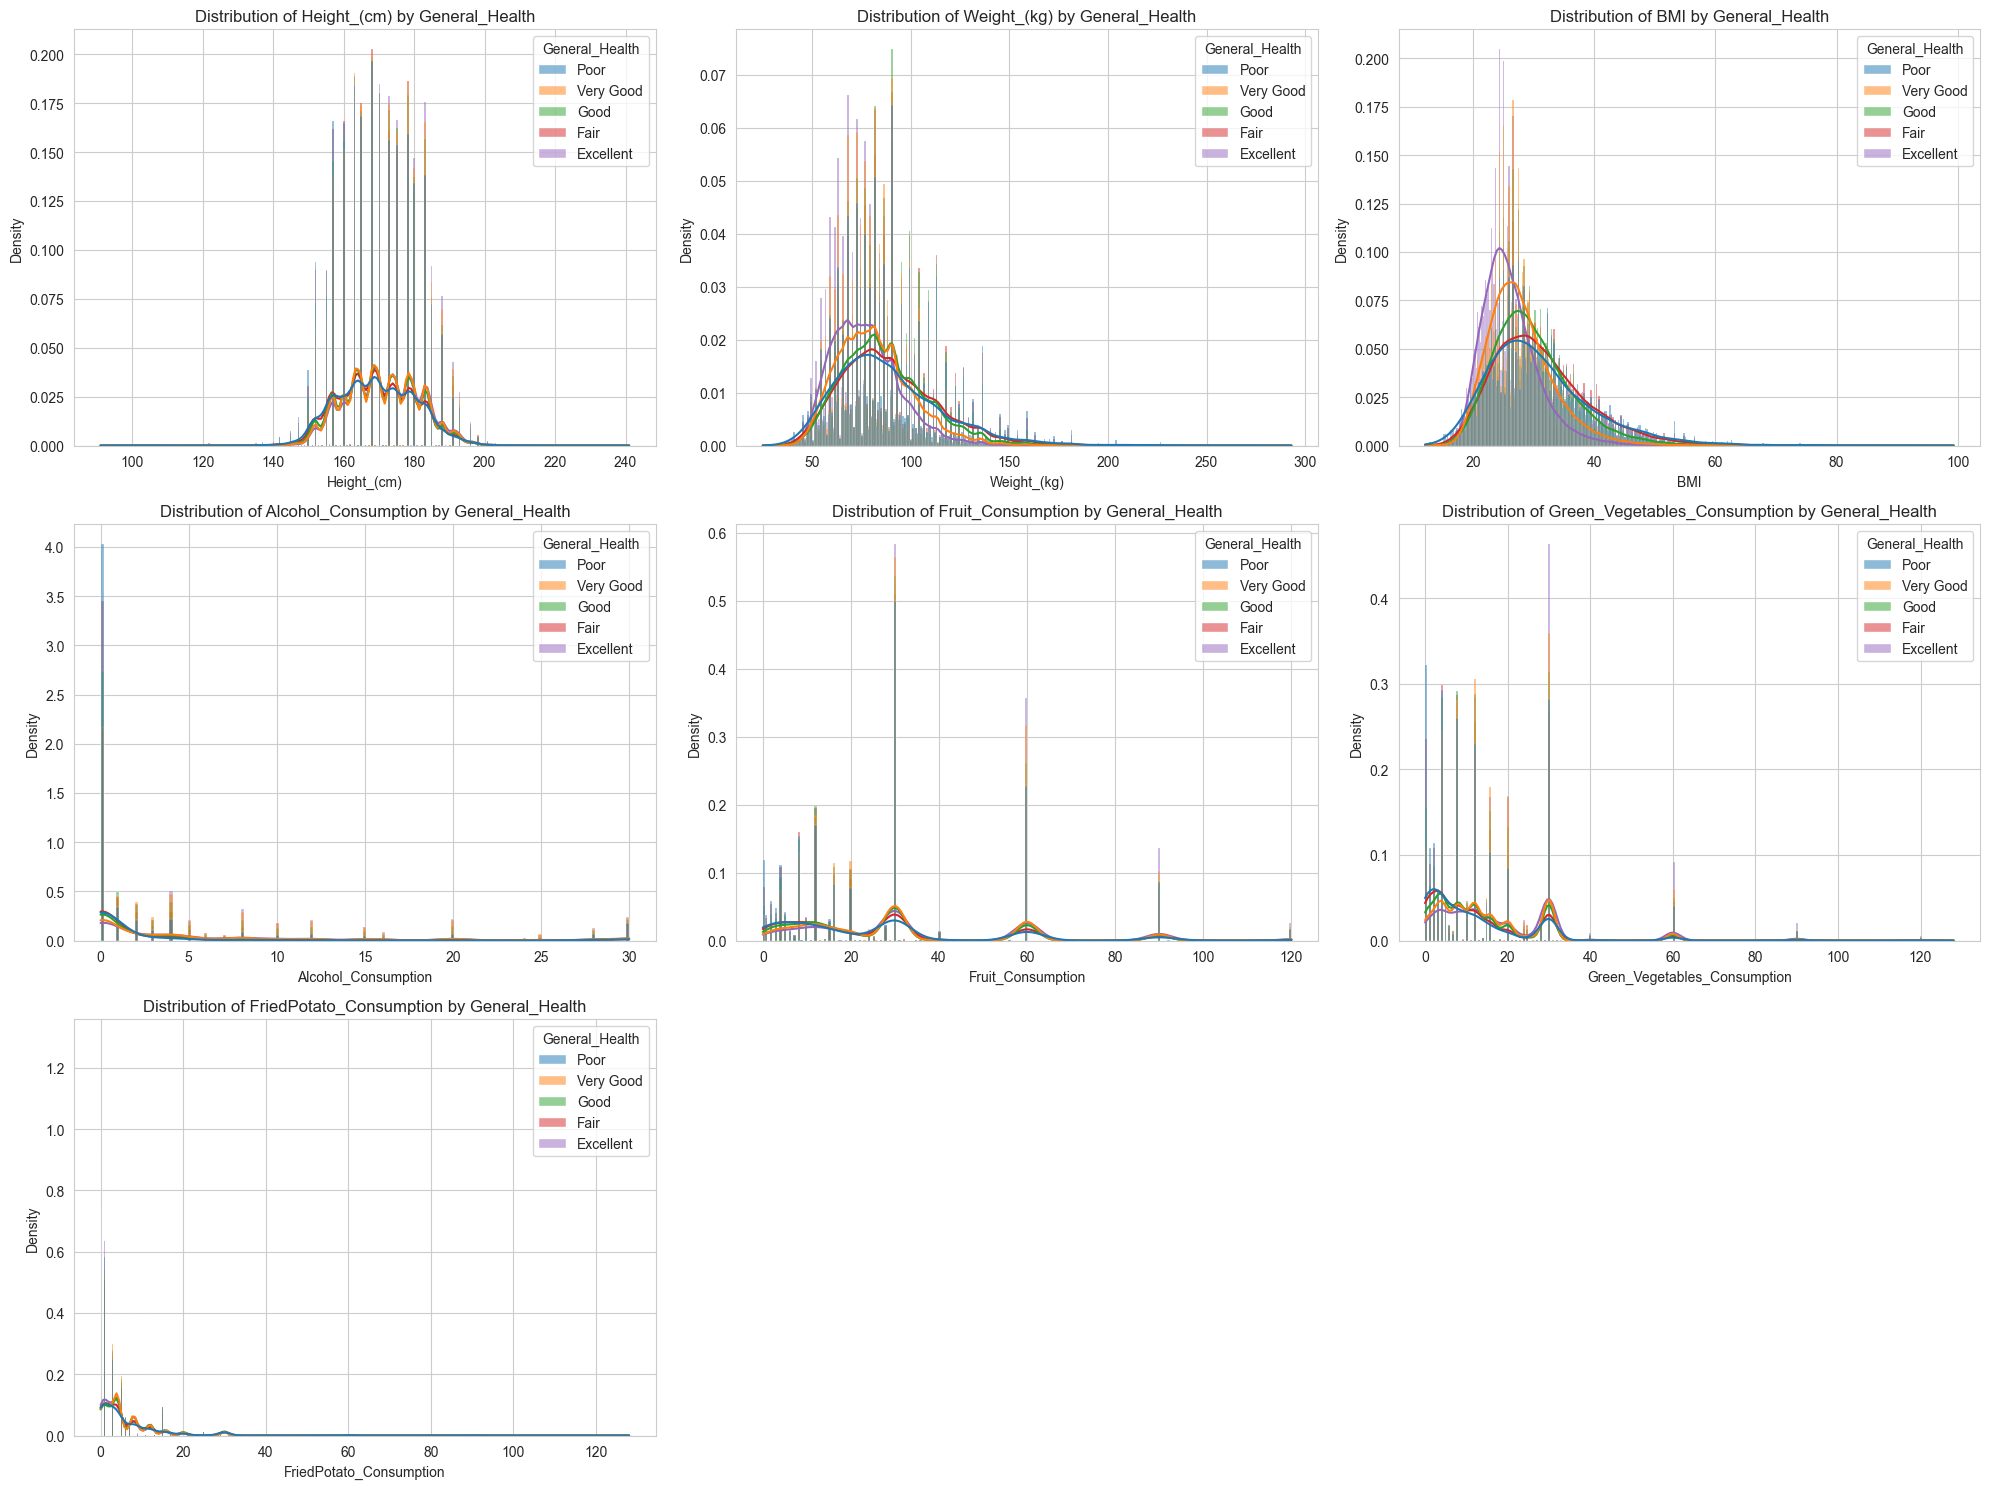

In [14]:

# 2. Distribution plots (histograms + KDE) for numerical features, with hue on target
n_nums = len(numerical_cols)
rows = (n_nums // 3) + (1 if n_nums % 3 else 0)

plt.figure(figsize=(20, 5 * rows))
for i, col in enumerate(numerical_cols):
    plt.subplot(rows, 3, i + 1)
    sns.histplot(data=df, x=col, kde=True, hue=target, stat="density", common_norm=False)
    plt.title(f'Distribution of {col} by {target}')
plt.tight_layout()
plt.show()



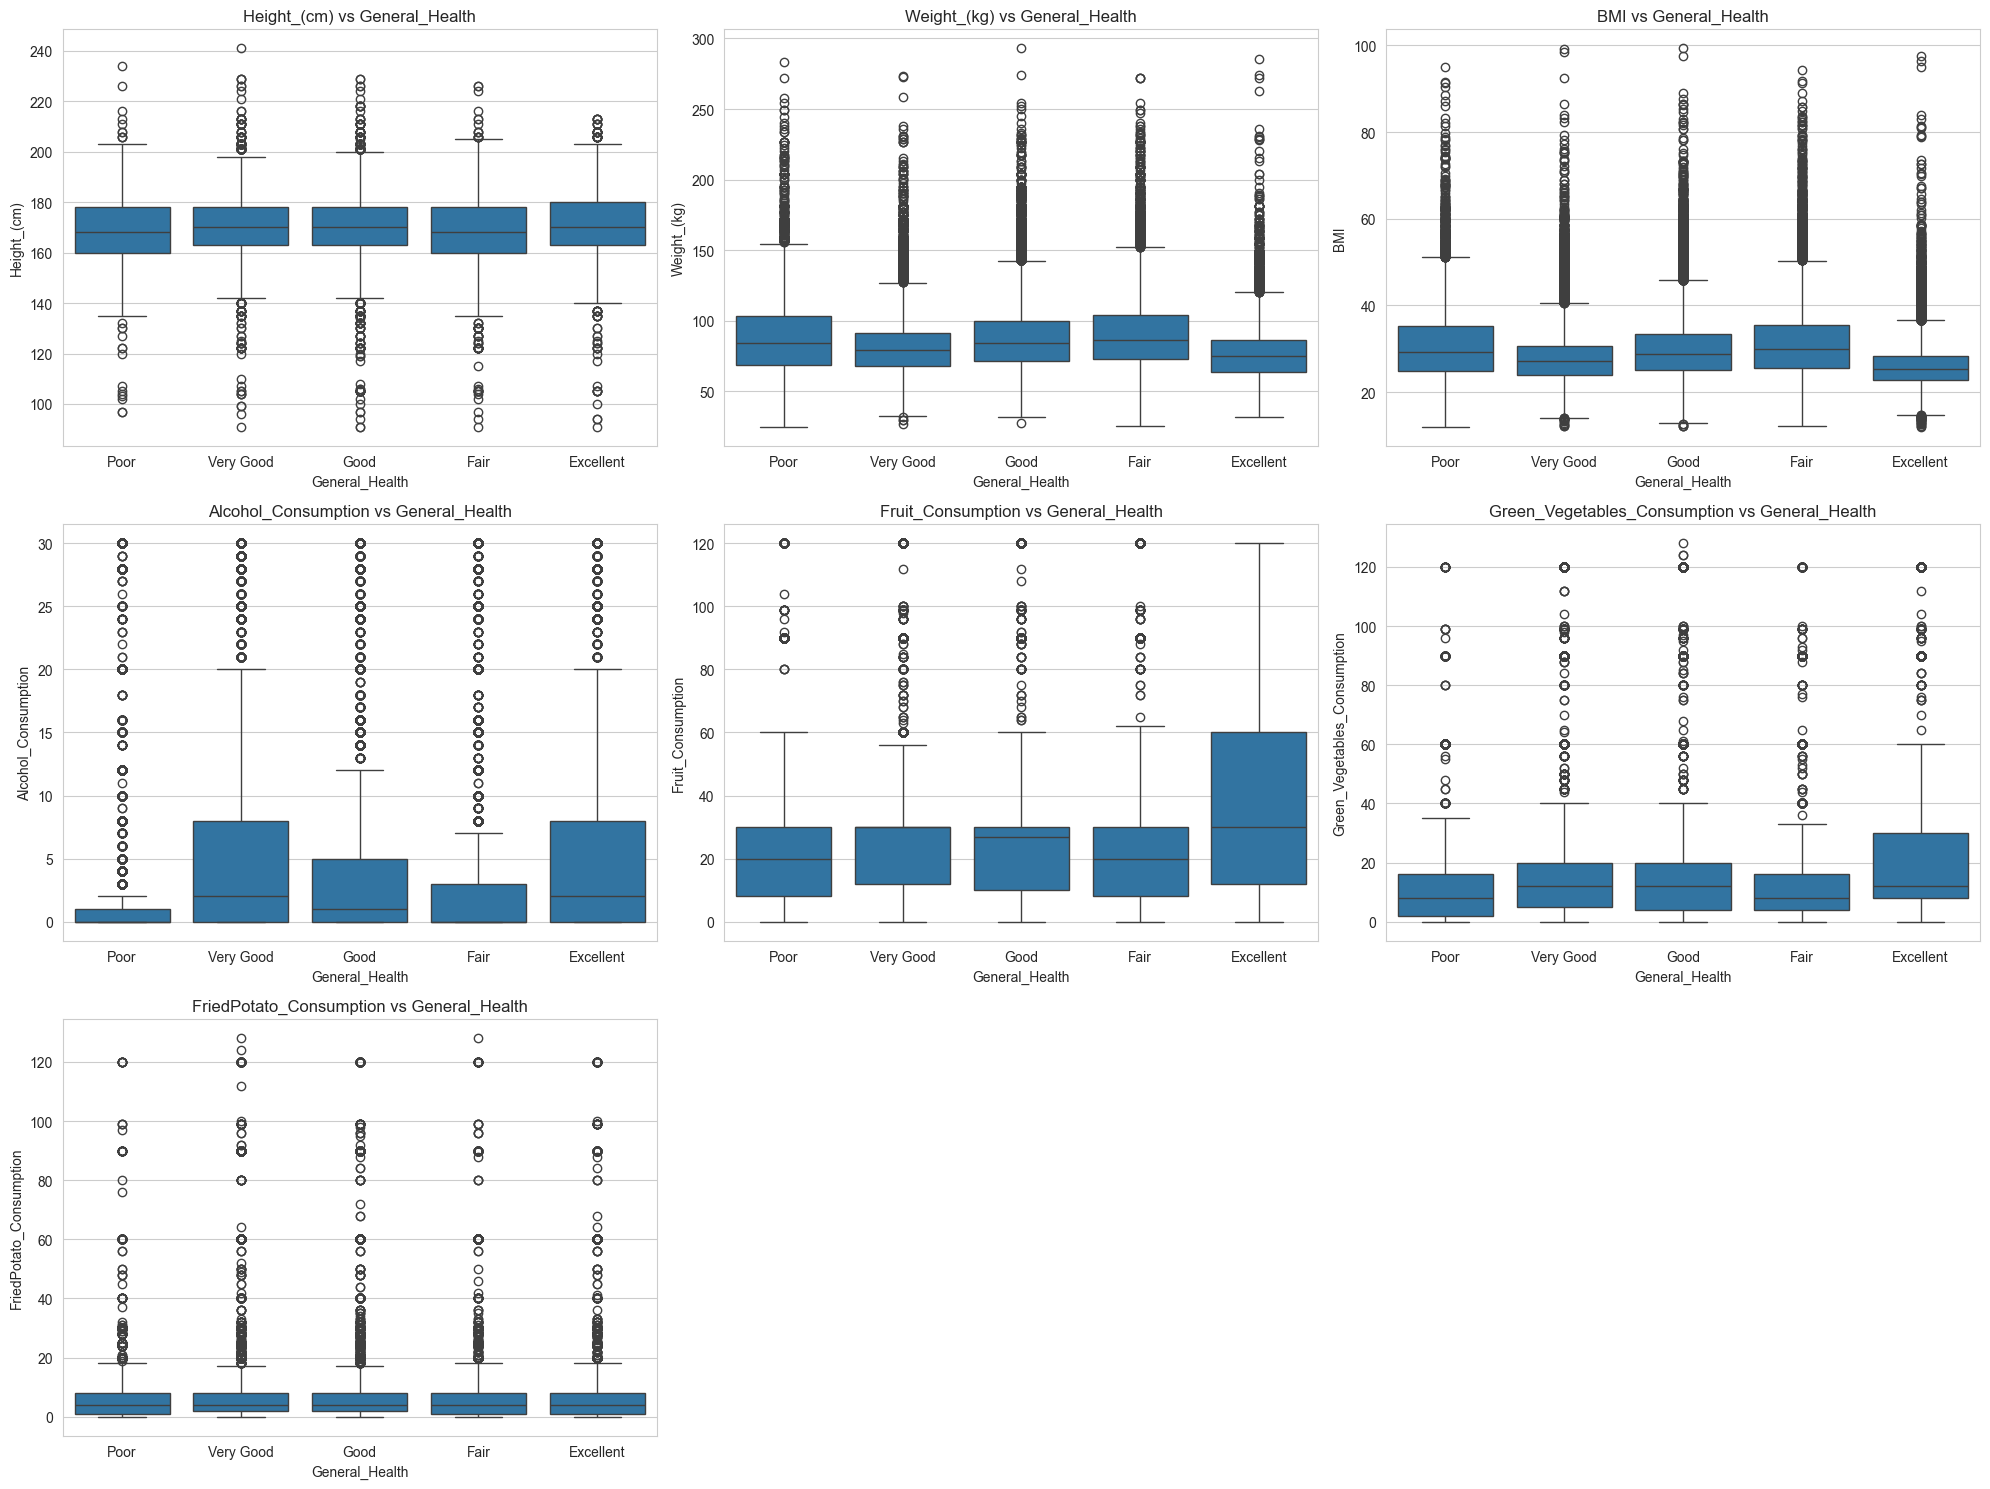

In [15]:
# 3. Box plots for numerical features vs target (to spot outliers and differences)
plt.figure(figsize=(20, 5 * rows))
for i, col in enumerate(numerical_cols):
    plt.subplot(rows, 3, i + 1)
    sns.boxplot(data=df, x=target, y=col)
    plt.title(f'{col} vs {target}')
plt.tight_layout()
plt.show()



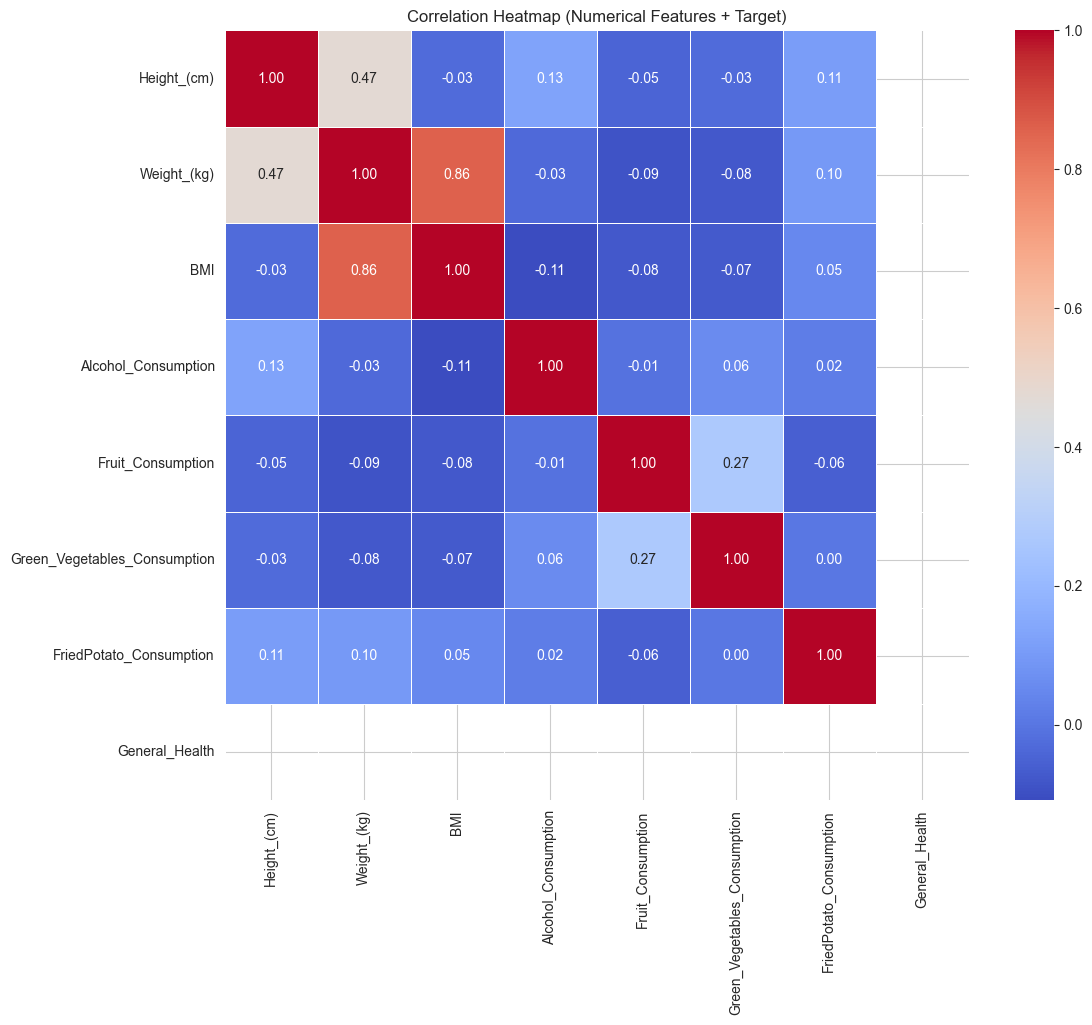

In [16]:
# 4. Correlation heatmap for numerical columns (including potential relations with target if encoded)
# First, temporarily encode target for correlation (Yes=1, No=0)
df_corr = df.copy()
df_corr[target] = df_corr[target].map({'Yes': 1, 'No': 0})

corr = df_corr[numerical_cols + [target]].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap (Numerical Features + Target)')
plt.show()



In [17]:
df_corr['General_Health'].value_counts()

Series([], Name: count, dtype: int64)

In [19]:
import pandas as pd
from scipy.stats.mstats import winsorize
import numpy as np

# List of numerical columns with potential outliers
numerical_cols = [
    'Height_(cm)', 'Weight_(kg)', 'BMI',
    'Alcohol_Consumption', 'Fruit_Consumption',
    'Green_Vegetables_Consumption', 'FriedPotato_Consumption'
]

# Create a copy of the dataframe to keep original intact
df_capped = df.copy()

# Apply winsorization: cap at 1% (lower) and 99% (upper) percentiles
# You can adjust limits (e.g., 0.05 and 0.95 for 5%) if needed
lower_limit = 0.01  # 1st percentile
upper_limit = 0.99  # 99th percentile

for col in numerical_cols:
    df_capped[col] = winsorize(df_capped[col], limits=(lower_limit, 1 - upper_limit))

# Optional: Convert back to float (winsorize returns masked array sometimes)
for col in numerical_cols:
    df_capped[col] = df_capped[col].astype(float)

print("Outliers have been capped using winsorization (1% and 99% limits).")
print("\nNew descriptive statistics after capping:")
print(df_capped[numerical_cols].describe())

Outliers have been capped using winsorization (1% and 99% limits).

New descriptive statistics after capping:
         Height_(cm)    Weight_(kg)            BMI  Alcohol_Consumption  \
count  308774.000000  308774.000000  308774.000000        308774.000000   
mean      170.625367      83.432232      28.575675             5.097557   
std        10.382607      20.509949       6.223541             8.200434   
min       150.000000      47.630000      18.010000             0.000000   
25%       163.000000      68.040000      24.210000             0.000000   
50%       170.000000      81.650000      27.440000             1.000000   
75%       178.000000      95.250000      31.850000             6.000000   
max       193.000000     147.420000      49.500000            30.000000   

       Fruit_Consumption  Green_Vegetables_Consumption  \
count      308774.000000                 308774.000000   
mean           29.834290                     14.765440   
std            24.877812                

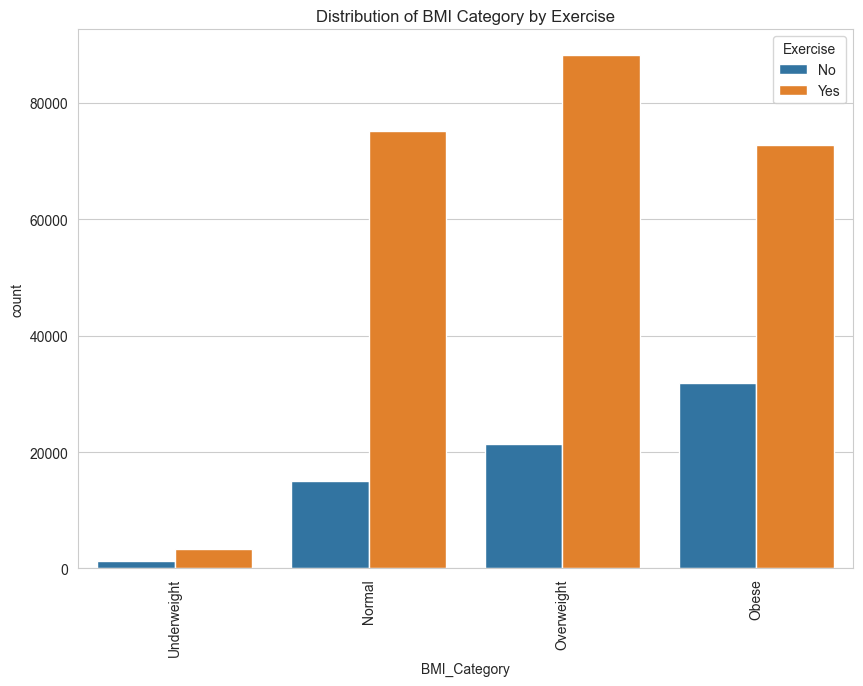

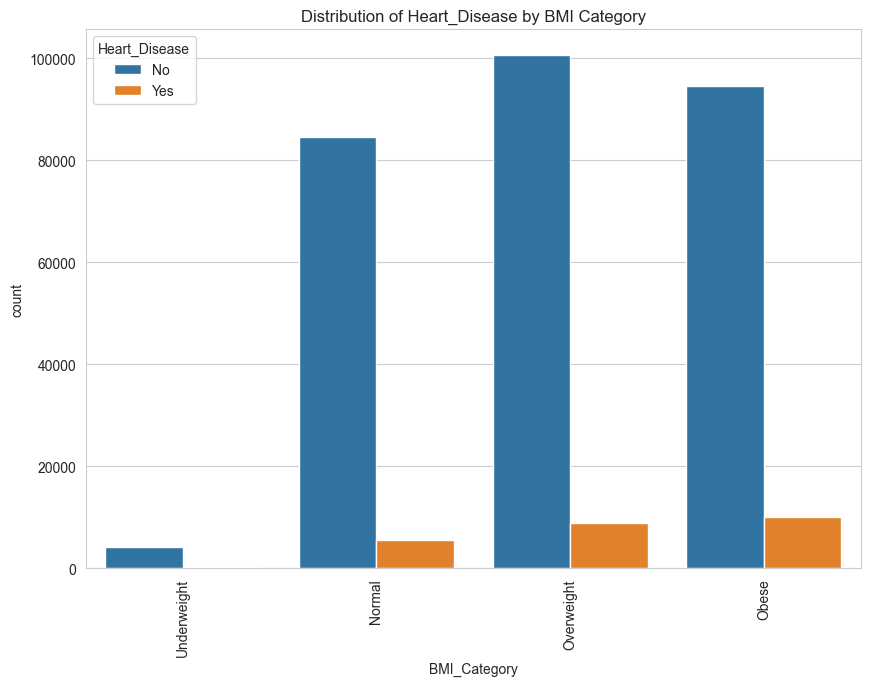

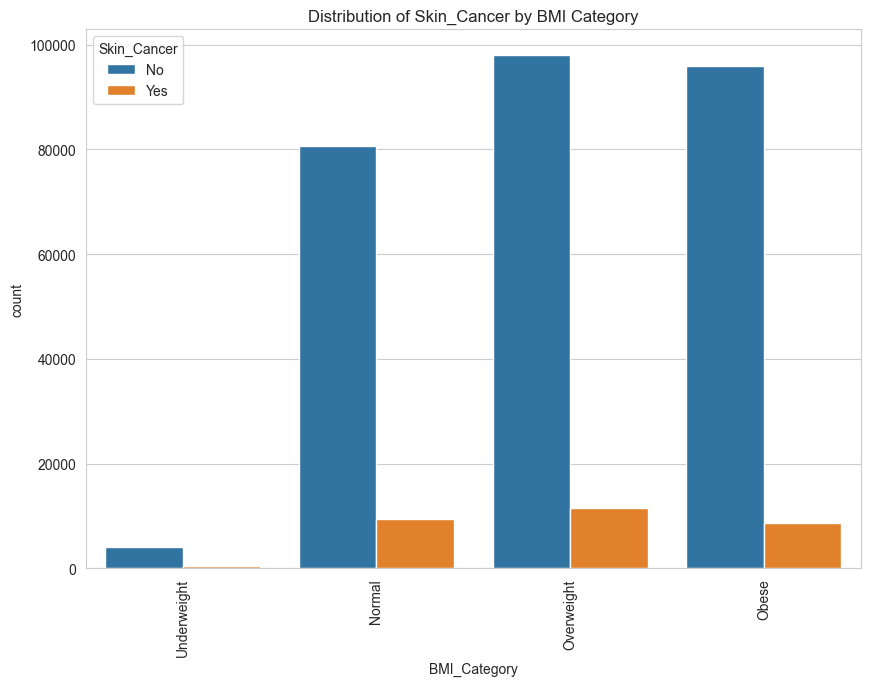

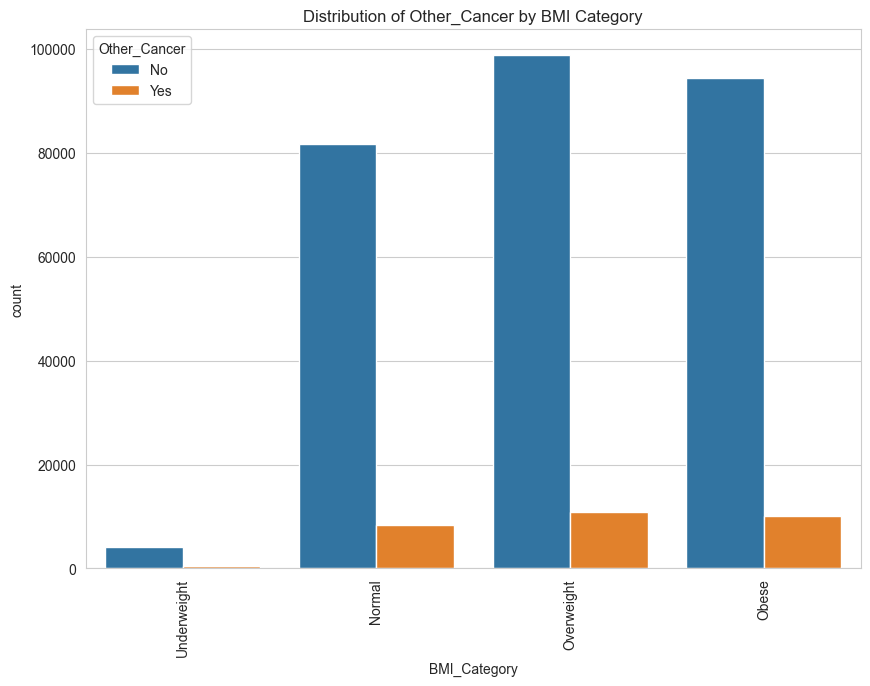

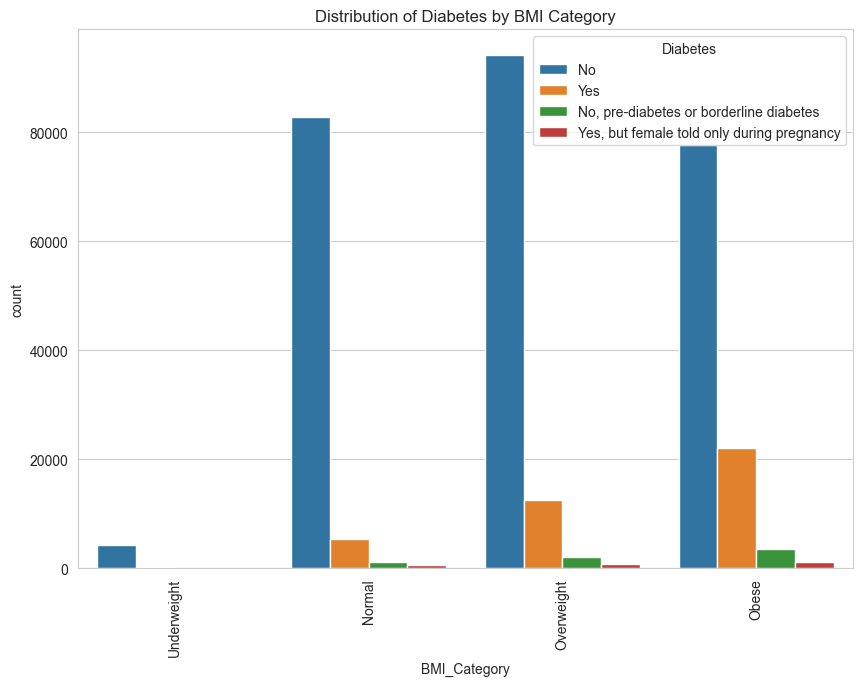

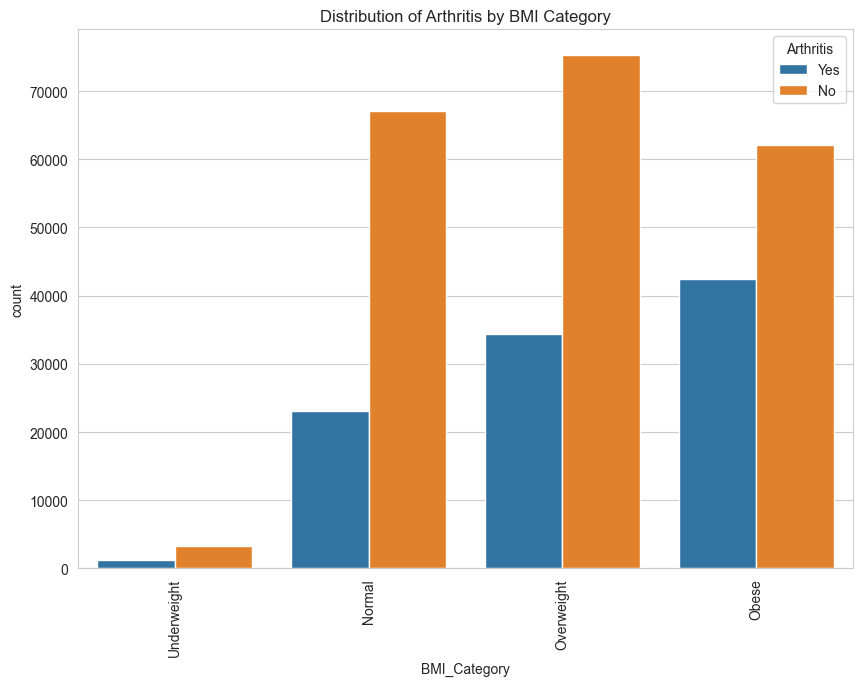

In [ ]:
# Analyze the relationship between disease conditions, BMI, and exercise
selected_variables = ['General_Health', 'Exercise', 'Sex', 'Age_Category', 'Smoking_History']

disease_conditions = ['Heart_Disease', 'Skin_Cancer', 'Other_Cancer', 'Diabetes', 'Arthritis']
# Creating a new BMI category
df['BMI_Category'] = pd.cut(df['BMI'], bins=[0,18.5,25,30,100], labels=['Underweight','Normal','Overweight','Obese'])

plt.figure(figsize=(10, 7))
sns.countplot(data=df, x='BMI_Category', hue='Exercise')
plt.title('Distribution of BMI Category by Exercise')
plt.xticks(rotation=90)
plt.show()

for disease in disease_conditions:
    plt.figure(figsize=(10, 7))
    sns.countplot(data=df, x='BMI_Category', hue=disease)
    plt.title('Distribution of ' + disease + ' by BMI Category')
    plt.xticks(rotation=90)
    plt.show()


🔍 Interpretation of Results:¶
The distribution of BMI Category by Exercise shows that individuals who exercise have a higher proportion of "Normal" BMI, while those who do not exercise have a higher proportion of "Overweight" and "Obese" BMI. This suggests that exercise is associated with healthier BMI levels. 🏋️‍♀️

The relationship between BMI Category and the disease conditions (Heart_Disease, Skin_Cancer, Other_Cancer, Diabetes, Arthritis) shows the following patterns:

For ❤️ Heart_Disease, 🩸 Diabetes, and 💪 Arthritis, the prevalence is higher among those with "Overweight" and "Obese" BMI. This suggests that these conditions may be associated with higher BMI levels.

For 🌞 Skin_Cancer and 🦀 Other_Cancer, the prevalence seems to be more evenly distributed across the different BMI categories. This could suggest that these types of cancer may not be as strongly associated with BMI as the other conditions.

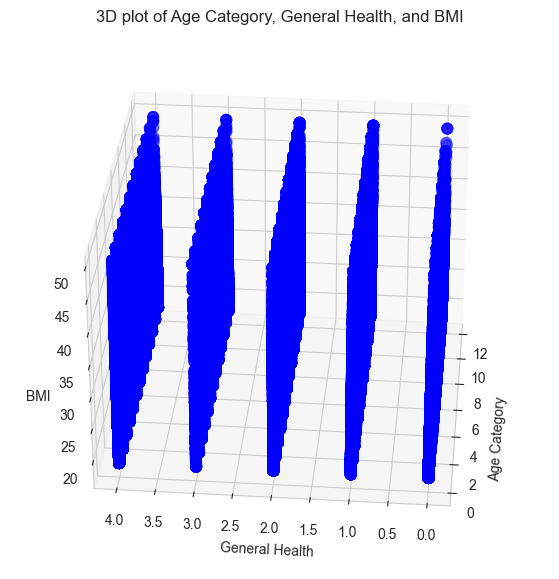

In [22]:
# We need to encode categorical variables to numerical values for 3D plotting
le = LabelEncoder()

# Selecting three features for 3D plot: Age_Category, General_Health, and BMI
data_3D = df_capped[['Age_Category', 'General_Health', 'BMI']].copy()

# Encode the categorical variables
data_3D['Age_Category'] = le.fit_transform(data_3D['Age_Category'])
data_3D['General_Health'] = le.fit_transform(data_3D['General_Health'])

# Create the 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data_3D['Age_Category'], data_3D['General_Health'], data_3D['BMI'], c='blue', s=60)
ax.view_init(30, 185)
plt.xlabel("Age Category")
plt.ylabel("General Health")
ax.set_zlabel('BMI')
plt.title('3D plot of Age Category, General Health, and BMI')
plt.show()

In [23]:
df_capped['General_Health'].value_counts()

General_Health
Very Good    110351
Good          95355
Excellent     55929
Fair          35808
Poor          11331
Name: count, dtype: int64

C:\Users\1158\AppData\Local\Temp\ipykernel_11700\3238326838.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='General_Health', data=df_capped, palette='Set2')


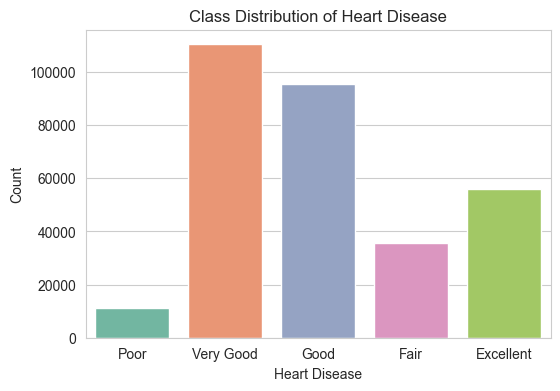

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='General_Health', data=df_capped, palette='Set2')
plt.title("Class Distribution of Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()


In [25]:
from sklearn.utils import resample

# Set the target class count
target_count = 35000

# List of all classes in General_Health
classes = df_capped['General_Health'].unique()

# Create an empty list to store the resampled data
resampled_data = []

# For each class in 'General_Health', perform oversampling to make each class have 35,000 records
for cls in classes:
    # Filter data for the current class
    class_data = df_capped[df_capped['General_Health'] == cls]
    
    # If the class has fewer than the target_count, oversample it
    if len(class_data) < target_count:
        class_data_oversampled = resample(class_data,
                                          replace=True,     # sample with replacement
                                          n_samples=target_count, # match target size
                                          random_state=42)
        resampled_data.append(class_data_oversampled)
    else:
        # If the class has more than or equal to the target_count, just sample the top 35,000 records
        class_data_resampled = class_data.sample(n=target_count, random_state=42)
        resampled_data.append(class_data_resampled)

# Combine all the resampled data into one DataFrame
df_balanced = pd.concat(resampled_data)

# Shuffle the dataset (to mix the samples from all classes)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Check the balance after resampling
print(df_balanced['General_Health'].value_counts())


General_Health
Excellent    35000
Fair         35000
Poor         35000
Good         35000
Very Good    35000
Name: count, dtype: int64


In [26]:
df_balanced.dtypes

General_Health                   object
Checkup                          object
Exercise                         object
Heart_Disease                    object
Skin_Cancer                      object
Other_Cancer                     object
Depression                       object
Diabetes                         object
Arthritis                        object
Sex                              object
Age_Category                     object
Height_(cm)                     float64
Weight_(kg)                     float64
BMI                             float64
Smoking_History                  object
Alcohol_Consumption             float64
Fruit_Consumption               float64
Green_Vegetables_Consumption    float64
FriedPotato_Consumption         float64
dtype: object

In [28]:
object_cols = df_capped.select_dtypes(include='object').columns
 # Loop through each object column and print unique values as arrays 
for col in object_cols:
  print(f"{col}: {df[col].unique()}")

General_Health: ['Poor' 'Very Good' 'Good' 'Fair' 'Excellent']
Checkup: ['Within the past 2 years' 'Within the past year' '5 or more years ago'
 'Within the past 5 years' 'Never']
Exercise: ['No' 'Yes']
Heart_Disease: ['No' 'Yes']
Skin_Cancer: ['No' 'Yes']
Other_Cancer: ['No' 'Yes']
Depression: ['No' 'Yes']
Diabetes: ['No' 'Yes' 'No, pre-diabetes or borderline diabetes'
 'Yes, but female told only during pregnancy']
Arthritis: ['Yes' 'No']
Sex: ['Female' 'Male']
Age_Category: ['70-74' '60-64' '75-79' '80+' '65-69' '50-54' '45-49' '18-24' '30-34'
 '55-59' '35-39' '40-44' '25-29']
Smoking_History: ['Yes' 'No']


In [29]:
from sklearn.preprocessing import LabelEncoder

# Make a copy of your balanced dataset
df_encoded = df_balanced.copy()

# Apply Label Encoding to all categorical columns
for col in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Check the result
print(df_encoded.head())


   General_Health  Checkup  Exercise  Heart_Disease  Skin_Cancer  \
0               0        4         1              0            0   
1               0        2         1              0            0   
2               1        4         1              0            0   
3               3        4         0              1            0   
4               3        4         0              0            0   

   Other_Cancer  Depression  Diabetes  Arthritis  Sex  Age_Category  \
0             0           0         0          0    0             6   
1             0           0         0          0    1             2   
2             0           0         2          0    1             8   
3             0           1         2          1    0            12   
4             0           1         2          0    0             8   

   Height_(cm)  Weight_(kg)    BMI  Smoking_History  Alcohol_Consumption  \
0        185.0       113.40  32.98                0                  0.0   
1        188

In [30]:
label_mappings = {}
for col in df_balanced.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_balanced[col])
    label_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print(label_mappings)


{'General_Health': {'Excellent': np.int64(0), 'Fair': np.int64(1), 'Good': np.int64(2), 'Poor': np.int64(3), 'Very Good': np.int64(4)}, 'Checkup': {'5 or more years ago': np.int64(0), 'Never': np.int64(1), 'Within the past 2 years': np.int64(2), 'Within the past 5 years': np.int64(3), 'Within the past year': np.int64(4)}, 'Exercise': {'No': np.int64(0), 'Yes': np.int64(1)}, 'Heart_Disease': {'No': np.int64(0), 'Yes': np.int64(1)}, 'Skin_Cancer': {'No': np.int64(0), 'Yes': np.int64(1)}, 'Other_Cancer': {'No': np.int64(0), 'Yes': np.int64(1)}, 'Depression': {'No': np.int64(0), 'Yes': np.int64(1)}, 'Diabetes': {'No': np.int64(0), 'No, pre-diabetes or borderline diabetes': np.int64(1), 'Yes': np.int64(2), 'Yes, but female told only during pregnancy': np.int64(3)}, 'Arthritis': {'No': np.int64(0), 'Yes': np.int64(1)}, 'Sex': {'Female': np.int64(0), 'Male': np.int64(1)}, 'Age_Category': {'18-24': np.int64(0), '25-29': np.int64(1), '30-34': np.int64(2), '35-39': np.int64(3), '40-44': np.int64

In [38]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df_encoded.drop(columns=['General_Health'], axis=1)
y = df_encoded['General_Health']

# Split into train and test sets (train size = total - 5000, test size = 5000)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=5000, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (170000, 18)
Testing set size: (5000, 18)


In [39]:
X_train.columns

Index(['Checkup', 'Exercise', 'Heart_Disease', 'Skin_Cancer', 'Other_Cancer',
       'Depression', 'Diabetes', 'Arthritis', 'Sex', 'Age_Category',
       'Height_(cm)', 'Weight_(kg)', 'BMI', 'Smoking_History',
       'Alcohol_Consumption', 'Fruit_Consumption',
       'Green_Vegetables_Consumption', 'FriedPotato_Consumption'],
      dtype='object')

## Random Forest

Random Forest Results:
              precision    recall  f1-score   support

           0       0.46      0.56      0.51      1000
           1       0.48      0.51      0.49      1000
           2       0.33      0.26      0.29      1000
           3       0.88      0.96      0.92      1000
           4       0.32      0.27      0.29      1000

    accuracy                           0.51      5000
   macro avg       0.49      0.51      0.50      5000
weighted avg       0.49      0.51      0.50      5000

Confusion Matrix:
 [[562  75 112   5 246]
 [ 91 511 210  78 110]
 [205 301 260  38 196]
 [  2  22  10 961   5]
 [355 164 203  13 265]]


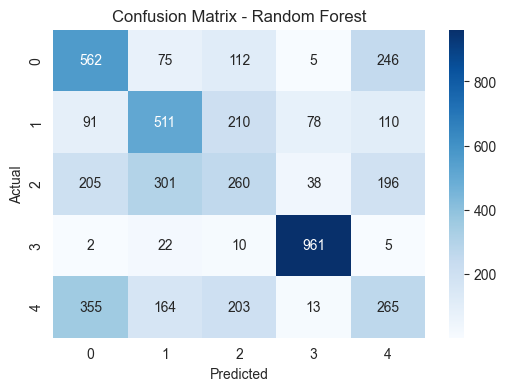

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Classification report
print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=set(y_test), 
            yticklabels=set(y_test))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()


Support Vector Machine Results:
              precision    recall  f1-score   support

           0       0.42      0.60      0.49      1000
           1       0.30      0.17      0.22      1000
           2       0.31      0.23      0.26      1000
           3       0.42      0.62      0.50      1000
           4       0.32      0.25      0.28      1000

    accuracy                           0.37      5000
   macro avg       0.35      0.37      0.35      5000
weighted avg       0.35      0.37      0.35      5000

Confusion Matrix:
 [[603  40 116  57 184]
 [118 170 139 458 115]
 [239 147 227 222 165]
 [108 119  90 625  58]
 [383  89 155 124 249]]


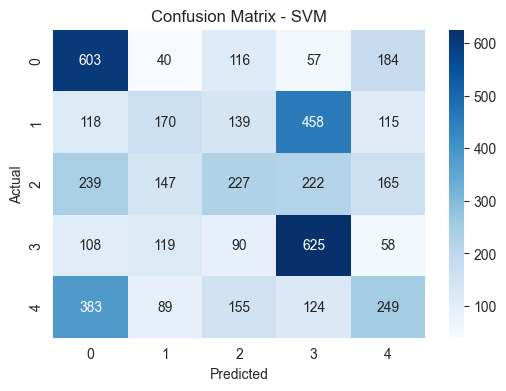

In [41]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train Support Vector Machine (SVM) classifier
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)

# Predictions
y_pred_svm = svm_clf.predict(X_test)

# Classification report
print("Support Vector Machine Results:")
print(classification_report(y_test, y_pred_svm))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:\n", cm)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=svm_clf.classes_,
            yticklabels=svm_clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()


Passive-Aggressive Classifier Results:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1000
           1       0.30      0.31      0.30      1000
           2       0.21      0.84      0.34      1000
           3       0.67      0.00      0.01      1000
           4       0.00      0.00      0.00      1000

    accuracy                           0.23      5000
   macro avg       0.24      0.23      0.13      5000
weighted avg       0.24      0.23      0.13      5000

Confusion Matrix:
 [[  0  10 990   0   0]
 [  0 310 688   2   0]
 [  0 160 840   0   0]
 [  0 508 488   4   0]
 [  0  55 945   0   0]]


C:\Users\1158\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\1158\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\1158\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

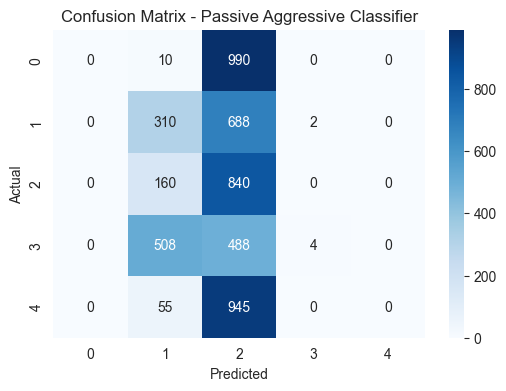

In [42]:
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize Passive-Aggressive Classifier
pa_clf = PassiveAggressiveClassifier(max_iter=1000, random_state=42)

# Train the model
pa_clf.fit(X_train, y_train)

# Predictions
y_pred_pa = pa_clf.predict(X_test)

# Classification report
print("Passive-Aggressive Classifier Results:")
print(classification_report(y_test, y_pred_pa))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_pa)
print("Confusion Matrix:\n", cm)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=pa_clf.classes_,
            yticklabels=pa_clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Passive Aggressive Classifier")
plt.show()


In [34]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))


# Perform 5-fold cross-validation
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')

print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())


# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid search with 5-fold CV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)
y_pred_best = best_rf.predict(X_test)

print("Tuned Random Forest Results:")
print(classification_report(y_test, y_pred_best))


KeyboardInterrupt: 

## XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# 5-fold cross-validation
cv_scores = cross_val_score(xgb, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)
best_xgb = grid_search.best_estimator_
best_xgb.fit(X_train, y_train)
y_pred_xgb = best_xgb.predict(X_test)

from sklearn.metrics import classification_report
print("XGBoost Results:")
print(classification_report(y_test, y_pred_xgb))


C:\Users\1158\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [16:56:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\1158\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [16:56:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\1158\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [16:56:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\1158\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [16:56:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:7

Cross-validation scores: [0.42521429 0.42675    0.4295     0.43046429 0.42764286]
Mean CV accuracy: 0.42791428571428575


C:\Users\1158\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [17:14:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'colsample_bytree': 1, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Best CV Score: 0.44897857142857145


C:\Users\1158\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [17:14:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Results:
              precision    recall  f1-score   support

           0       0.45      0.57      0.50      7000
           1       0.41      0.38      0.39      7000
           2       0.30      0.23      0.26      7000
           3       0.67      0.80      0.73      7000
           4       0.33      0.29      0.31      7000

    accuracy                           0.45     35000
   macro avg       0.43      0.45      0.44     35000
weighted avg       0.43      0.45      0.44     35000



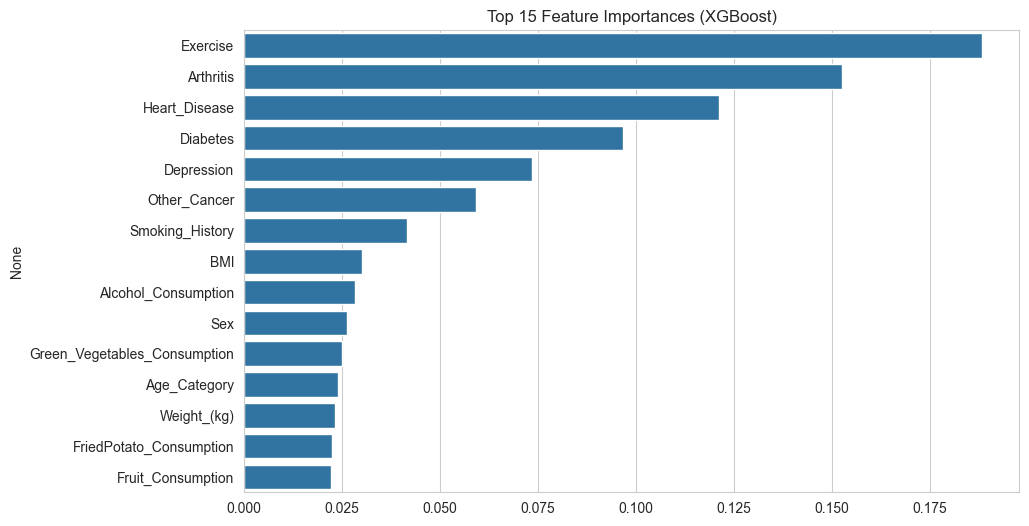

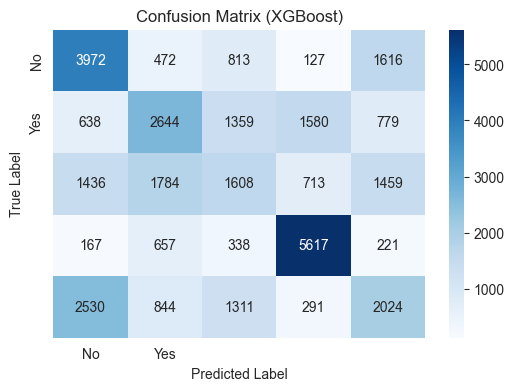

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Feature importance
plt.figure(figsize=(10,6))
importances = best_xgb.feature_importances_
indices = np.argsort(importances)[::-1]
sns.barplot(x=importances[indices][:15], y=X_train.columns[indices][:15])
plt.title("Top 15 Feature Importances (XGBoost)")
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.title("Confusion Matrix (XGBoost)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()




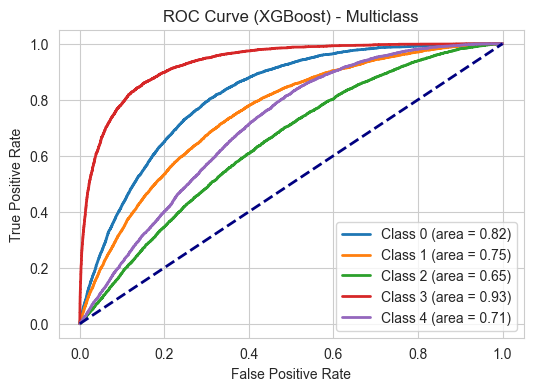

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the output for multiclass classification
y_test_binarized = label_binarize(y_test, classes=best_xgb.classes_)

# Get probabilities for each class
y_prob = best_xgb.predict_proba(X_test)

# ROC Curve for each class
plt.figure(figsize=(6,4))
fpr = {}
tpr = {}
roc_auc = {}
for i in range(len(best_xgb.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {best_xgb.classes_[i]} (area = {roc_auc[i]:.2f})')

# Plot the random chance line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (XGBoost) - Multiclass")
plt.legend(loc="lower right")
plt.show()


## CNN (Deep Learning)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Build CNN model
cnn = models.Sequential([
    layers.Reshape((X_train.shape[1], 1), input_shape=(X_train.shape[1],)),
    layers.Conv1D(64, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train CNN
cnn.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# Evaluate
cnn_eval = cnn.evaluate(X_test, y_test)
print("CNN Accuracy:", cnn_eval[1])


Epoch 1/10


c:\Users\1158\.conda\envs\imageclassification_3_12_12\Lib\site-packages\keras\src\layers\reshaping\reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4375/4375 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.2001 - loss: -19491986.0000 - val_accuracy: 0.2000 - val_loss: -246036320.0000
Epoch 2/10
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.2000 - loss: -449714176.0000 - val_accuracy: 0.2000 - val_loss: -1340347392.0000
Epoch 3/10
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.2010 - loss: -1813877120.0000 - val_accuracy: 0.2000 - val_loss: -3663789568.0000
Epoch 4/10
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.2014 - loss: -4502798336.0000 - val_accuracy: 0.2000 - val_loss: -7563163648.0000
Epoch 5/10
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.1979 - loss: -8948413440.0000 - val_accuracy: 0.2000 - val_loss: -13412916224.0000
Epoch 6/10
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.1990 - loss: -15327276032.0000 - val_accuracy: 0.2000 - val_loss: -21560610816.0000
Epoch 7/10
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.2007 - loss: -24093052928.0000 - val_accurac

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 760us/step


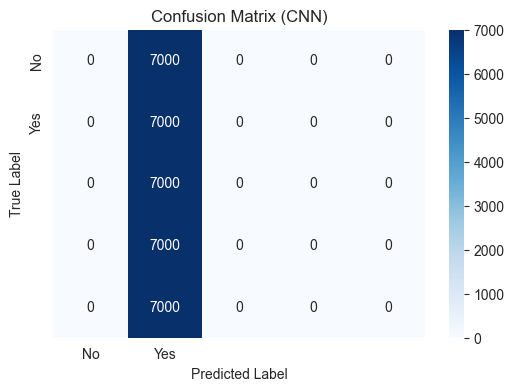

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred_cnn = (cnn.predict(X_test) > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.title("Confusion Matrix (CNN)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the true labels for multiclass
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))

# Get the predicted probabilities for each class
y_prob_cnn = cnn.predict(X_test)

# Initialize dictionaries to store ROC curve metrics
fpr = {}
tpr = {}
roc_auc = {}

# Calculate ROC curve for each class
for i in range(len(np.unique(y_test))):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_prob_cnn[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
plt.figure(figsize=(6,4))
for i in range(len(np.unique(y_test))):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (CNN)")
plt.legend(loc="lower right")
plt.show()


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 734us/step


IndexError: index 1 is out of bounds for axis 1 with size 1

In [ ]:
import joblib
# After training Random Forest
joblib.dump(rf, "random_forest_model.pkl")


['random_forest_model.pkl']

In [ ]:
import joblib
# After training Random Forest
joblib.dump(rf, "random_forest_model.pkl")

# Load it back
rf_loaded = joblib.load("random_forest_model.pkl")
# After training XGBoost
joblib.dump(xgb, "xgboost_model.pkl")

# Load it back
xgb_loaded = joblib.load("xgboost_model.pkl")
# Save CNN model
cnn.save("cnn_model.h5")

# Load it back
from tensorflow.keras.models import load_model
cnn_loaded = load_model("cnn_model.h5")
